In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [6]:
df = pd.read_csv(r"C:\Users\Jitesh Raskar\OneDrive\Desktop\HousePricePrediction\dataset.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [8]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [9]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [10]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 545
Columns : 13


In [11]:
df.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [12]:
df.select_dtypes(include=['object']).columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [13]:
binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for column in binary_columns:
    df[column] = df[column].map({'yes': 1, 'no': 0})

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [14]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['furnishingstatus'] = label_encoder.fit_transform(df['furnishingstatus'])

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


In [15]:
df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad            int64
guestroom           int64
basement            int64
hotwaterheating     int64
airconditioning     int64
parking             int64
prefarea            int64
furnishingstatus    int64
dtype: object

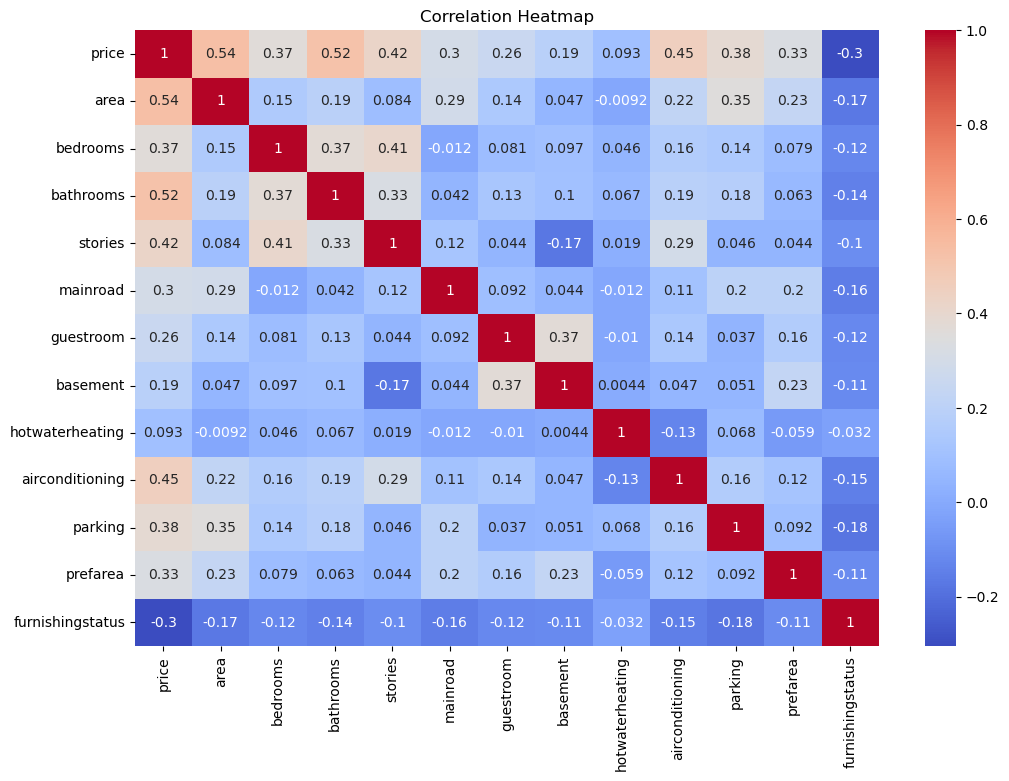

In [16]:
plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

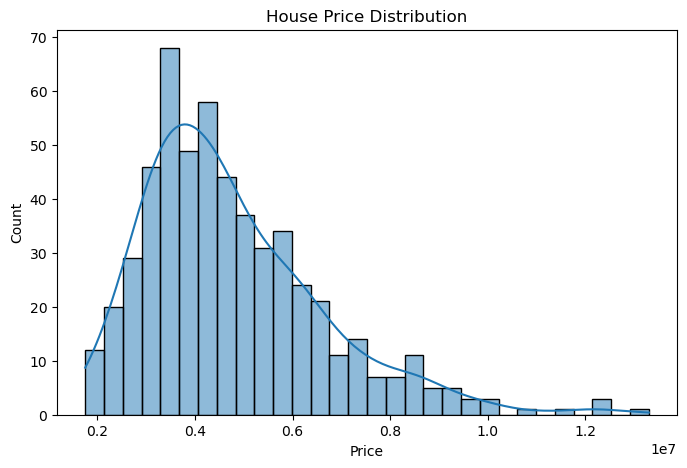

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(df['price'], bins=30, kde=True)

plt.title("House Price Distribution")

plt.xlabel("Price")

plt.ylabel("Count")

plt.show()

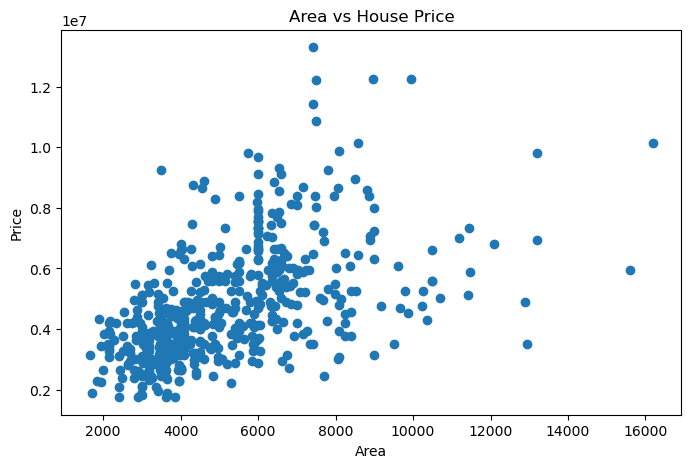

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(df['area'], df['price'])

plt.xlabel("Area")

plt.ylabel("Price")

plt.title("Area vs House Price")

plt.show()

In [19]:
X = df.drop('price', axis=1)

y = df['price']

print("Features Shape:", X.shape)

print("Target Shape:", y.shape)

Features Shape: (545, 12)
Target Shape: (545,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)

print("Testing Data:", X_test.shape)

Training Data: (436, 12)
Testing Data: (109, 12)


In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [22]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[5203691.70963178 7257004.02115476 3062828.59668171 4559591.65374424
 3332932.30559782 3563080.67918997 5645466.31219972 6413979.66873635
 2755831.54819    2668938.66075229]


In [23]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred.astype(int)
})

comparison.head(10)

,Actual Price,Predicted Price
0,4060000,5203691
1,6650000,7257004
2,3710000,3062828
3,6440000,4559591
4,2800000,3332932
5,4900000,3563080
6,5250000,5645466
7,4543000,6413979
8,2450000,2755831
9,3353000,2668938


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)

print("Mean Squared Error:", mse)

print("Root Mean Squared Error:", rmse)

print("R² Score:", r2)

Mean Absolute Error: 979679.6912959905
Mean Squared Error: 1771751116594.0344
Root Mean Squared Error: 1331071.4167895103
R² Score: 0.6494754192267804


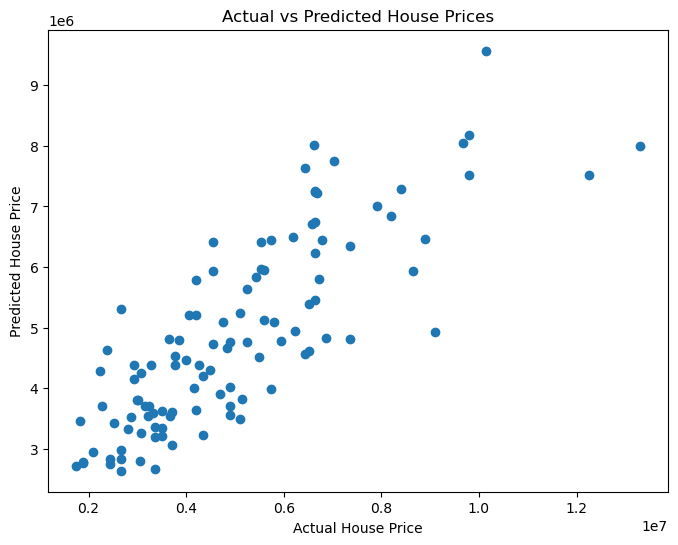

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Price")

plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

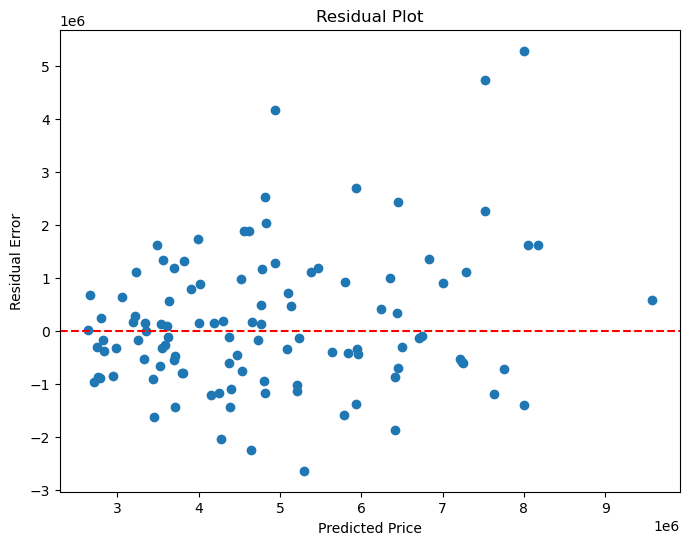

In [26]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Price")

plt.ylabel("Residual Error")

plt.title("Residual Plot")

plt.show()

In [27]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance = importance.sort_values(by="Coefficient", ascending=False)

importance

,Feature,Coefficient
2,bathrooms,1.097117e+06
8,airconditioning,7.855506e+05
7,hotwaterheating,6.878813e+05
10,prefarea,6.299017e+05
3,stories,4.062232e+05
6,basement,3.931598e+05
4,mainroad,3.668242e+05
5,guestroom,2.331468e+05
9,parking,2.257565e+05
1,bedrooms,7.857449e+04


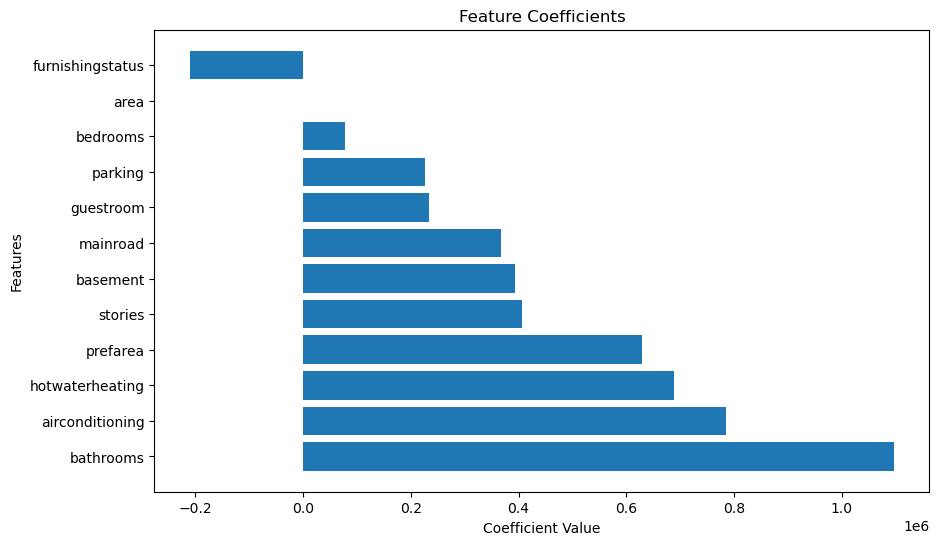

In [28]:
plt.figure(figsize=(10,6))

plt.barh(importance["Feature"], importance["Coefficient"])

plt.xlabel("Coefficient Value")

plt.ylabel("Features")

plt.title("Feature Coefficients")

plt.show()

In [29]:
import joblib

joblib.dump(model, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [30]:
joblib.dump(label_encoder, "label_encoder.pkl")

print("Label Encoder saved successfully!")

Label Encoder saved successfully!


In [31]:
import os

print(os.listdir())

['.anaconda', '.cache', '.claude', '.claude.json', '.codex', '.conda', '.continuum', '.copilot', '.gitconfig', '.insomniac', '.ipynb_checkpoints', '.ipython', '.jupyter', '.local', '.matplotlib', '.ollama', '.streamlit', '.vscode', '.vscode-shared', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'chatbot_confusion_matrix.png', 'chatbot_encoder.pkl', 'chatbot_model.pkl', 'chatbot_tfidf.pkl', 'cleaned_telco_churn.csv', 'Collegebot(2).ipynb', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'HousePricePrediction.ipynb', 'house_price_model.pkl', 'Internship(task 1).ipynb', 'label_encoder.pkl', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{03ee6e84-9792-11f0-92ab-9cc7d3c28b19}.TM.blf', 'NTUSER.DAT{03ee6e84-9792-11f0-92ab-9cc7d3c28b19}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{03ee6e84-9792-11f0-92ab-9cc7d3c28b19}.TMContainer00000000000000000002.regtrans-ms', 'ntuse